## obtendo graficos e metricas uteis dos modelos treinados

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [3]:
print("Diretório atual:")
print(Path.cwd())

Diretório atual:
c:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks


In [4]:
cwd = Path.cwd()

if (cwd / "src" / "models").exists():
    models_dir = cwd / "src" / "models"

elif (cwd.parent / "models").exists():
    # Caso o notebook esteja executando a partir de src/notebooks
    models_dir = cwd.parent / "models"

else:
    raise FileNotFoundError("Não foi possível localizar a pasta src/models.")

print("Pasta dos modelos:")
print(models_dir)

Pasta dos modelos:
c:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\models


In [5]:
modelos = [p for p in models_dir.iterdir() if p.is_dir()]

for i, modelo in enumerate(modelos):
    print(i, modelo.name)

0 yolov8s_foca_v4_800_50e
1 yolov8_nano_foca_v3_800_50e
2 yolov8_small_foca_v5


In [6]:
model_dir = modelos[1]

print("Modelo selecionado:")
print(model_dir)

Modelo selecionado:
c:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\models\yolov8_nano_foca_v3_800_50e


In [6]:
for arquivo in sorted(model_dir.iterdir()):
    print(arquivo.name)

args.yaml
BoxF1_curve.png
BoxP_curve.png
BoxPR_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch64400.jpg
train_batch64401.jpg
train_batch64402.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


In [7]:
results_path = model_dir / "results.csv"

df = pd.read_csv(results_path, skipinitialspace=True)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,551.989,1.87280,1.59624,1.18092,0.74220,0.49999,0.55239,0.27297,1.64744,1.11567,1.09270,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331
1,2,1024.770,1.70803,1.08563,1.07319,0.78593,0.51206,0.57234,0.28863,1.60417,0.94286,1.07765,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533
2,3,1469.980,1.72913,1.06438,1.08827,0.76915,0.48883,0.54945,0.28300,1.62592,0.99043,1.09735,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602
3,4,1906.800,1.72306,1.05230,1.08890,0.79186,0.51932,0.58768,0.30109,1.57944,0.90810,1.08439,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406
4,5,2341.580,1.66492,0.98363,1.07941,0.81243,0.53643,0.60784,0.31502,1.54409,0.87445,1.07225,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208


In [8]:
df.columns = df.columns.str.strip()

In [9]:
metricas = df[
    [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]
]

metricas.head()

,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,1,0.74220,0.49999,0.55239,0.27297
1,2,0.78593,0.51206,0.57234,0.28863
2,3,0.76915,0.48883,0.54945,0.28300
3,4,0.79186,0.51932,0.58768,0.30109
4,5,0.81243,0.53643,0.60784,0.31502


In [10]:
print("Número de épocas:", len(df))

print("\nÚltima época:")
display(
    df[
        [
            "epoch",
            "metrics/precision(B)",
            "metrics/recall(B)",
            "metrics/mAP50(B)",
            "metrics/mAP50-95(B)"
        ]
    ].tail(1)
)

Número de épocas: 50

Última época:


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
49,50,0.86363,0.63496,0.70885,0.38347


In [11]:
melhor_idx = df["metrics/mAP50-95(B)"].idxmax()

melhor_epoca = df.loc[
    melhor_idx,
    [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]
]

melhor_epoca

epoch                   49.00000
metrics/precision(B)     0.86300
metrics/recall(B)        0.63485
metrics/mAP50(B)         0.70876
metrics/mAP50-95(B)      0.38387
Name: 48, dtype: float64

In [ ]:
sns.set_theme(style="whitegrid")

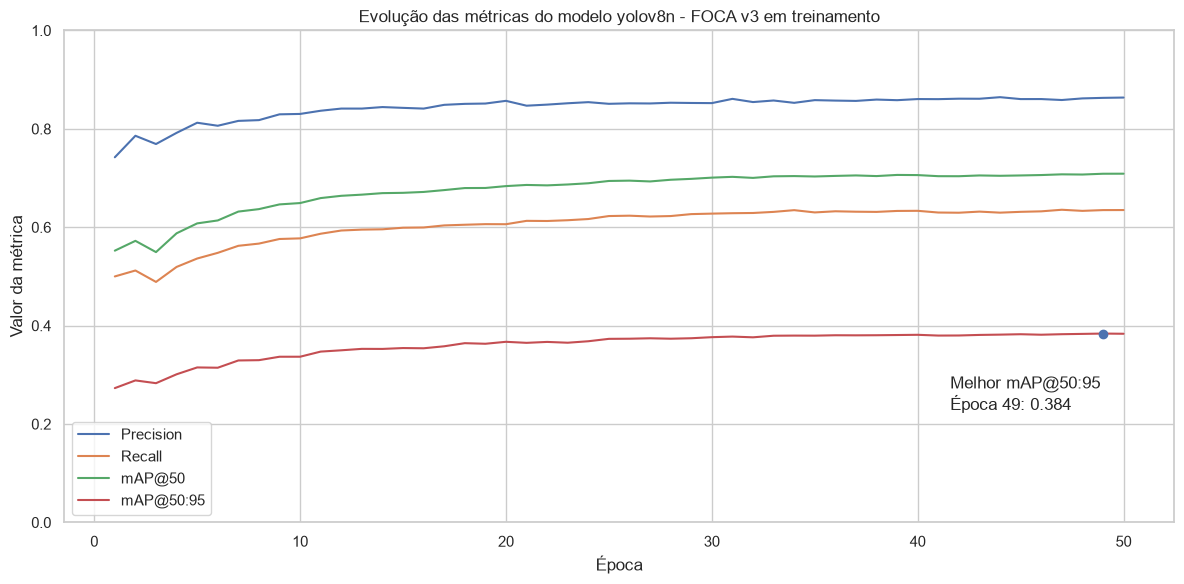

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/precision(B)",
    label="Precision"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/recall(B)",
    label="Recall"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/mAP50(B)",
    label="mAP@50"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/mAP50-95(B)",
    label="mAP@50:95"
)

melhor_idx = df["metrics/mAP50-95(B)"].idxmax()
melhor_epoca = df.loc[melhor_idx, "epoch"]
melhor_map = df.loc[melhor_idx, "metrics/mAP50-95(B)"]

plt.scatter(
    melhor_epoca,
    melhor_map,
    zorder=5
)

plt.annotate(
    f"Melhor mAP@50:95\nÉpoca {int(melhor_epoca)}: {melhor_map:.3f}",
    xy=(melhor_epoca, melhor_map),
    xytext=(-110, -55),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"}
)

plt.title("Evolução das métricas do modelo yolov8n - FOCA v3 em treinamento")
plt.xlabel("Época")
plt.ylabel("Valor da métrica")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "metricas_treinamento_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

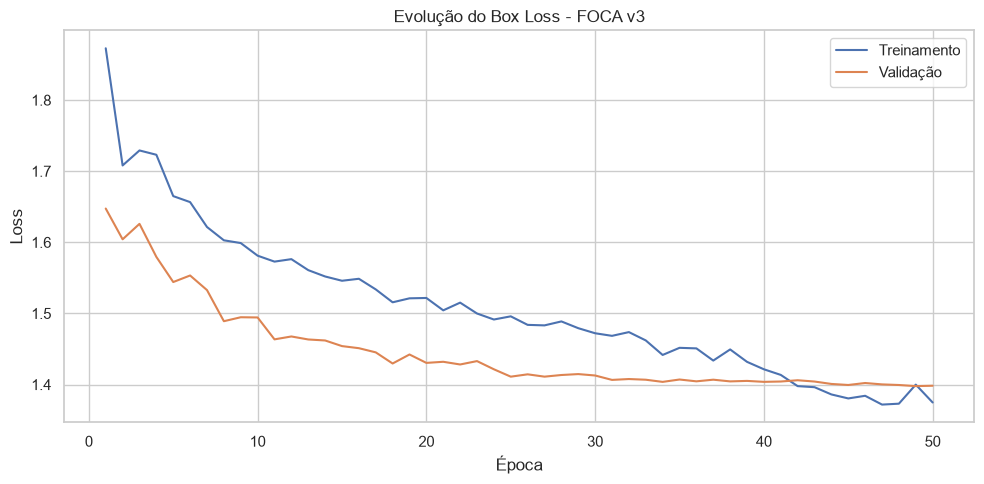

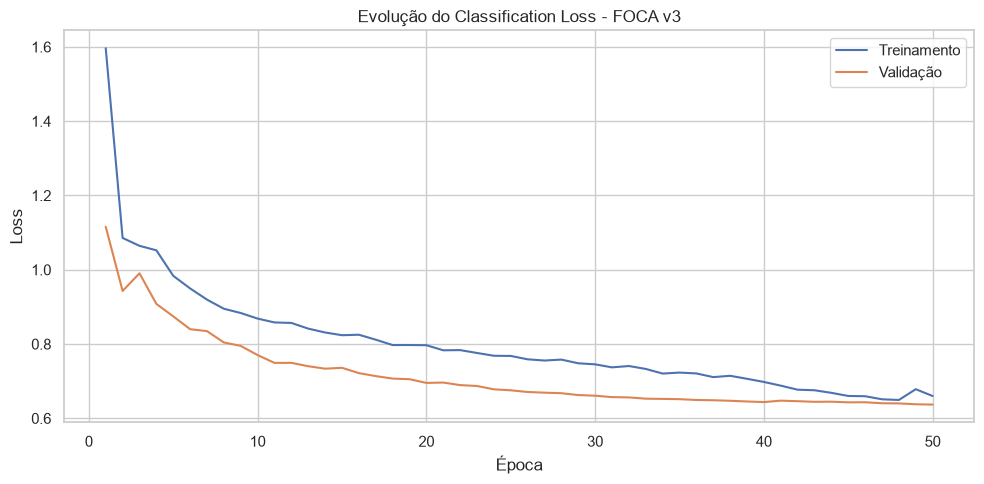

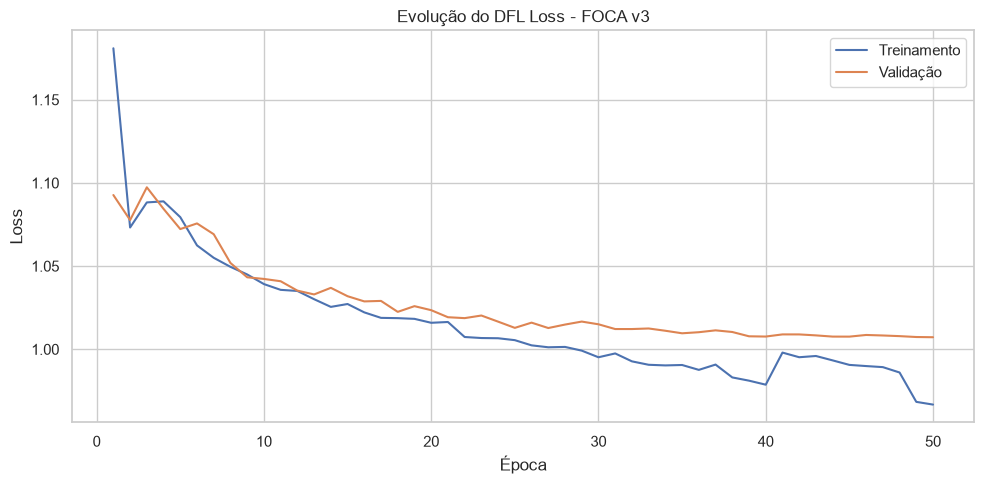

In [15]:
losses = {
    "Box Loss": ("train/box_loss", "val/box_loss"),
    "Classification Loss": ("train/cls_loss", "val/cls_loss"),
    "DFL Loss": ("train/dfl_loss", "val/dfl_loss")
}

for titulo, (train_col, val_col) in losses.items():
    plt.figure(figsize=(10, 5))

    sns.lineplot(
        data=df,
        x="epoch",
        y=train_col,
        label="Treinamento"
    )

    sns.lineplot(
        data=df,
        x="epoch",
        y=val_col,
        label="Validação"
    )

    plt.title(f"Evolução do {titulo} - FOCA v3")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    
    plt.legend()
    plt.tight_layout()

    plt.show()

In [16]:
loss_summary = pd.DataFrame({
    "Loss": [
        "Box Loss",
        "Classification Loss",
        "DFL Loss"
    ],
    
    "Treino inicial": [
        df["train/box_loss"].iloc[0],
        df["train/cls_loss"].iloc[0],
        df["train/dfl_loss"].iloc[0]
    ],
    
    "Treino final": [
        df["train/box_loss"].iloc[-1],
        df["train/cls_loss"].iloc[-1],
        df["train/dfl_loss"].iloc[-1]
    ],
    
    "Validação inicial": [
        df["val/box_loss"].iloc[0],
        df["val/cls_loss"].iloc[0],
        df["val/dfl_loss"].iloc[0]
    ],
    
    "Validação final": [
        df["val/box_loss"].iloc[-1],
        df["val/cls_loss"].iloc[-1],
        df["val/dfl_loss"].iloc[-1]
    ]
})

loss_summary.round(4)

,Loss,Treino inicial,Treino final,Validação inicial,Validação final
0,Box Loss,1.8728,1.3747,1.6474,1.3983
1,Classification Loss,1.5962,0.6600,1.1157,0.6369
2,DFL Loss,1.1809,0.9667,1.0927,1.0072


### Análise das funções de perda

As curvas de perda apresentam redução progressiva ao longo das 50 épocas,
indicando convergência do processo de treinamento.

O Classification Loss apresentou a maior redução, passando de 1,5962 para
0,6600 no conjunto de treinamento e de 1,1157 para 0,6369 na validação.

O Box Loss também apresentou queda consistente, indicando melhora na
localização das caixas delimitadoras dos rostos.

No DFL Loss, observa-se estabilização da perda de validação nas últimas épocas,
enquanto a perda de treinamento continua apresentando uma pequena redução.
Esse comportamento indica diminuição dos ganhos de generalização no final do
treinamento, porém sem evidência clara de overfitting, uma vez que as perdas
de validação não apresentam crescimento significativo.

In [17]:
from matplotlib.ticker import PercentFormatter

metricas_cols = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "mAP@50": "metrics/mAP50(B)",
    "mAP@50:95": "metrics/mAP50-95(B)"
}

comparacao = pd.DataFrame({
    "Métrica": list(metricas_cols.keys()),
    "Época 1": [
        df[col].iloc[0]
        for col in metricas_cols.values()
    ],
    "Época 50": [
        df[col].iloc[-1]
        for col in metricas_cols.values()
    ]
})

comparacao

,Métrica,Época 1,Época 50
0,Precision,0.74220,0.86363
1,Recall,0.49999,0.63496
2,mAP@50,0.55239,0.70885
3,mAP@50:95,0.27297,0.38347


In [18]:
comparacao_long = comparacao.melt(
    id_vars="Métrica",
    var_name="Momento",
    value_name="Valor"
)

comparacao_long

,Métrica,Momento,Valor
0,Precision,Época 1,0.74220
1,Recall,Época 1,0.49999
2,mAP@50,Época 1,0.55239
3,mAP@50:95,Época 1,0.27297
4,Precision,Época 50,0.86363
5,Recall,Época 50,0.63496
6,mAP@50,Época 50,0.70885
7,mAP@50:95,Época 50,0.38347


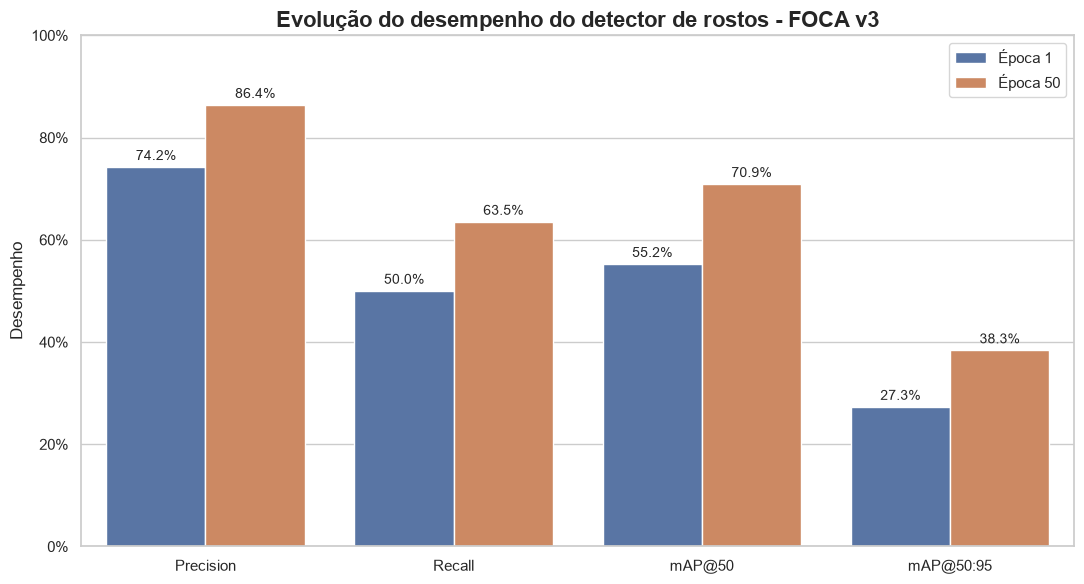

In [20]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparacao_long,
    x="Métrica",
    y="Valor",
    hue="Momento"
)

ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.title(
    "Evolução do desempenho do detector de rostos - FOCA v3",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Desempenho")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x * 100:.1f}%",
        padding=3,
        fontsize=10
    )

plt.legend(title="")
plt.tight_layout()

plt.savefig(
    "evolucao_metricas_colunas_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## principais
mAP@50: 55,2% → 70,9%

Precision: 74,2% → 86,4%

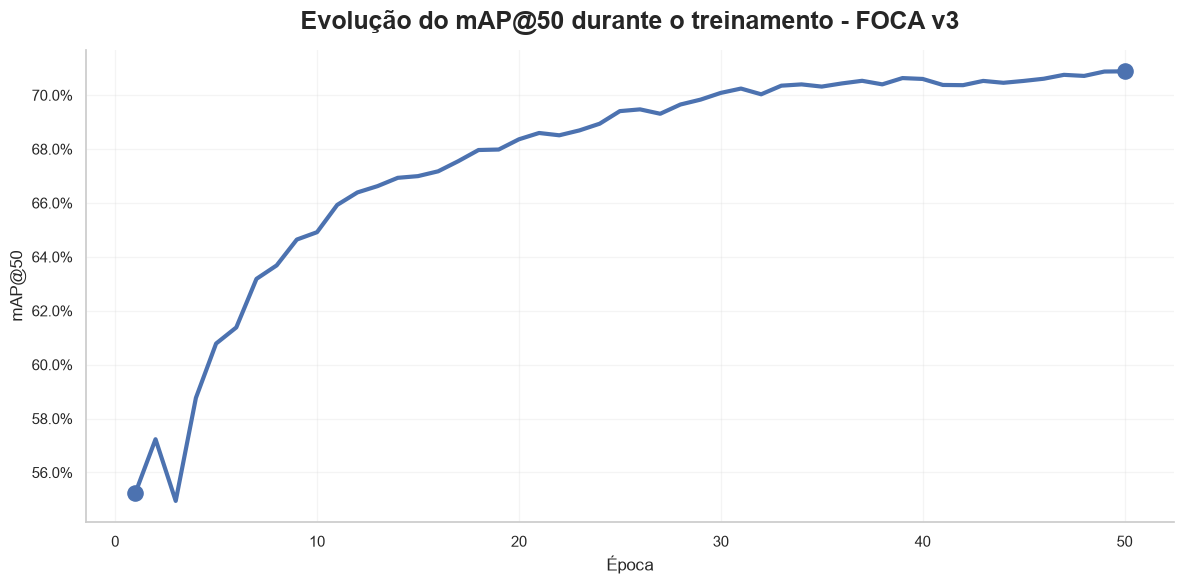

In [21]:
from matplotlib.ticker import PercentFormatter

# Dados
epocas = df["epoch"]
map50 = df["metrics/mAP50(B)"]

map_inicial = map50.iloc[0]
map_final = map50.iloc[-1]

epoca_inicial = epocas.iloc[0]
epoca_final = epocas.iloc[-1]

ganho_pp = (map_final - map_inicial) * 100

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    x=epocas,
    y=map50,
    ax=ax,
    linewidth=3
)

# Pontos inicial e final
ax.scatter(
    [epoca_inicial, epoca_final],
    [map_inicial, map_final],
    s=120,
    zorder=5
)

# # Valor inicial
# ax.annotate(
#     f"{map_inicial:.1%}",
#     xy=(epoca_inicial, map_inicial),
#     xytext=(15, -25),
#     textcoords="offset points",
#     fontsize=12,
#     fontweight="bold"
# )

# # Valor final
# ax.annotate(
#     f"{map_final:.1%}",
#     xy=(epoca_final, map_final),
#     xytext=(-45, 15),
#     textcoords="offset points",
#     fontsize=12,
#     fontweight="bold"
# )

# Configuração
ax.set_title(
    "Evolução do mAP@50 durante o treinamento - FOCA v3",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("mAP@50", fontsize=12)

ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.grid(alpha=0.2)

sns.despine()

plt.tight_layout()

plt.savefig(
    "evolucao_map50_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

grafico tuff

PRECISION
86,4%
Precisão das detecções

RECALL
63,5%
Rostos detectados

mAP@50
70,9%
Desempenho geral

mAP@50:95
38,3%
Avaliação rigorosa

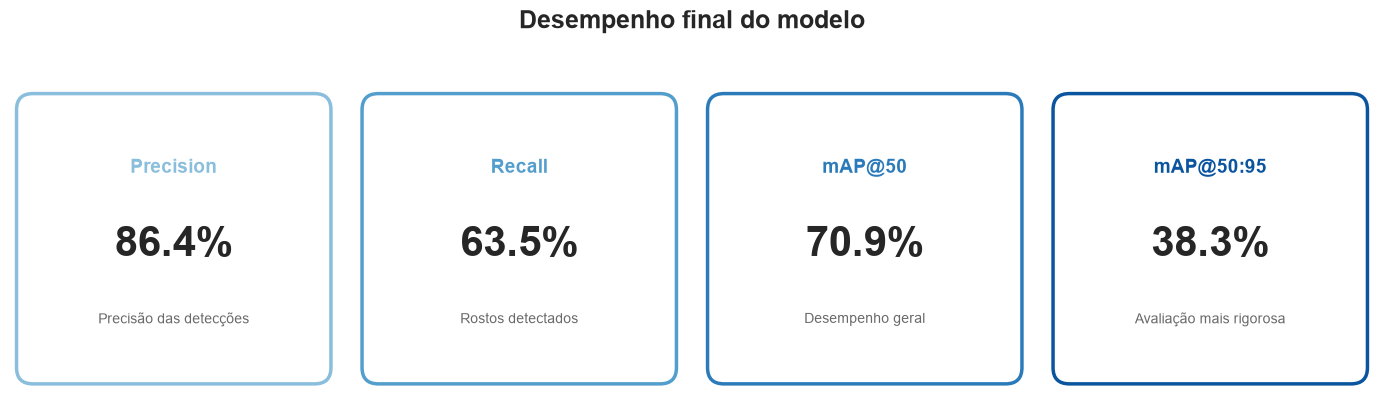

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Valores da última época
metricas_cards = {
    "Precision": df["metrics/precision(B)"].iloc[-1],
    "Recall": df["metrics/recall(B)"].iloc[-1],
    "mAP@50": df["metrics/mAP50(B)"].iloc[-1],
    "mAP@50:95": df["metrics/mAP50-95(B)"].iloc[-1]
}

descricoes = {
    "Precision": "Precisão das detecções",
    "Recall": "Rostos detectados",
    "mAP@50": "Desempenho geral",
    "mAP@50:95": "Avaliação mais rigorosa"
}

sns.set_theme(style="white")

cores = sns.color_palette("Blues", 6)[2:]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(14, 4)
)

for ax, (nome, valor), cor in zip(
    axes,
    metricas_cards.items(),
    cores
):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Card
    card = FancyBboxPatch(
        (0.05, 0.08),
        0.9,
        0.84,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        facecolor="white",
        edgecolor=cor,
        linewidth=2.5
    )

    ax.add_patch(card)

    # Nome da métrica
    ax.text(
        0.5,
        0.72,
        nome,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color=cor
    )

    # Valor principal
    ax.text(
        0.5,
        0.48,
        f"{valor:.1%}",
        ha="center",
        va="center",
        fontsize=30,
        fontweight="bold"
    )

    # Descrição
    ax.text(
        0.5,
        0.25,
        descricoes[nome],
        ha="center",
        va="center",
        fontsize=10,
        color="dimgray"
    )

fig.suptitle(
    "Desempenho final do modelo",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "cards_metricas_finais_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## metricas e graficos v4

In [5]:
model_dir = modelos[2]

print("Modelo selecionado:")
print(model_dir)

Modelo selecionado:
c:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\models\yolov8_small_foca_v5


In [7]:
results_path = model_dir / "results.csv"

df = pd.read_csv(results_path, skipinitialspace=True)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,476.306,1.80594,1.15596,1.14164,0.80603,0.55978,0.64504,0.32541,1.58054,0.82790,1.05906,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331
1,2,907.213,1.64342,0.91293,1.03083,0.82177,0.56587,0.65250,0.32724,1.59270,0.83877,1.05122,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533
2,3,1328.330,1.68394,0.96151,1.04754,0.79248,0.55612,0.62731,0.32228,1.58599,0.92167,1.06751,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602
3,4,1756.750,1.68611,0.97213,1.04848,0.82061,0.57086,0.65656,0.33627,1.55815,0.85567,1.04844,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406
4,5,2180.300,1.63596,0.91212,1.04334,0.82813,0.58174,0.67236,0.34924,1.52881,0.80183,1.04183,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208


In [8]:
df.columns = df.columns.str.strip()

In [9]:
metricas = df[
    [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]
]

metricas.head()

,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,1,0.80603,0.55978,0.64504,0.32541
1,2,0.82177,0.56587,0.65250,0.32724
2,3,0.79248,0.55612,0.62731,0.32228
3,4,0.82061,0.57086,0.65656,0.33627
4,5,0.82813,0.58174,0.67236,0.34924


In [10]:
print("Número de épocas:", len(df))

print("\nÚltima época:")
display(
    df[
        [
            "epoch",
            "metrics/precision(B)",
            "metrics/recall(B)",
            "metrics/mAP50(B)",
            "metrics/mAP50-95(B)"
        ]
    ].tail(1)
)

Número de épocas: 50

Última época:


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
49,50,0.87647,0.69421,0.77878,0.42291


In [11]:
melhor_idx = df["metrics/mAP50-95(B)"].idxmax()

melhor_epoca = df.loc[
    melhor_idx,
    [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]
]

melhor_epoca

epoch                   39.00000
metrics/precision(B)     0.87289
metrics/recall(B)        0.69701
metrics/mAP50(B)         0.78105
metrics/mAP50-95(B)      0.42665
Name: 38, dtype: float64

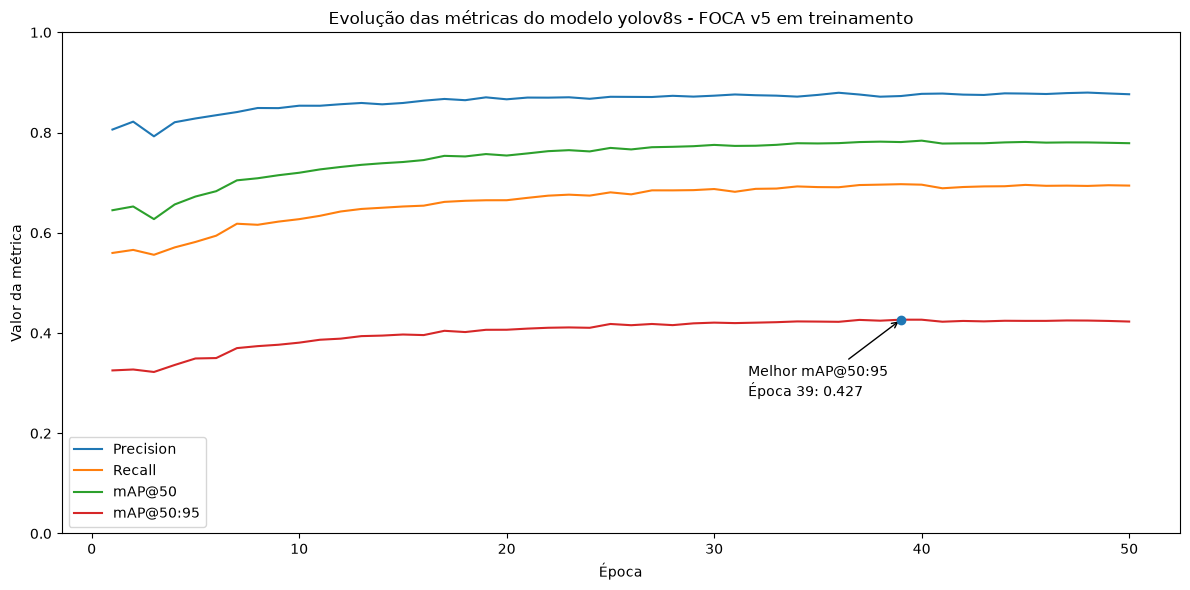

In [12]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/precision(B)",
    label="Precision"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/recall(B)",
    label="Recall"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/mAP50(B)",
    label="mAP@50"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/mAP50-95(B)",
    label="mAP@50:95"
)

melhor_idx = df["metrics/mAP50-95(B)"].idxmax()
melhor_epoca = df.loc[melhor_idx, "epoch"]
melhor_map = df.loc[melhor_idx, "metrics/mAP50-95(B)"]

plt.scatter(
    melhor_epoca,
    melhor_map,
    zorder=5
)

plt.annotate(
    f"Melhor mAP@50:95\nÉpoca {int(melhor_epoca)}: {melhor_map:.3f}",
    xy=(melhor_epoca, melhor_map),
    xytext=(-110, -55),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"}
)

plt.title("Evolução das métricas do modelo yolov8s - FOCA v5 em treinamento")
plt.xlabel("Época")
plt.ylabel("Valor da métrica")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "metricas_treinamento_v5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

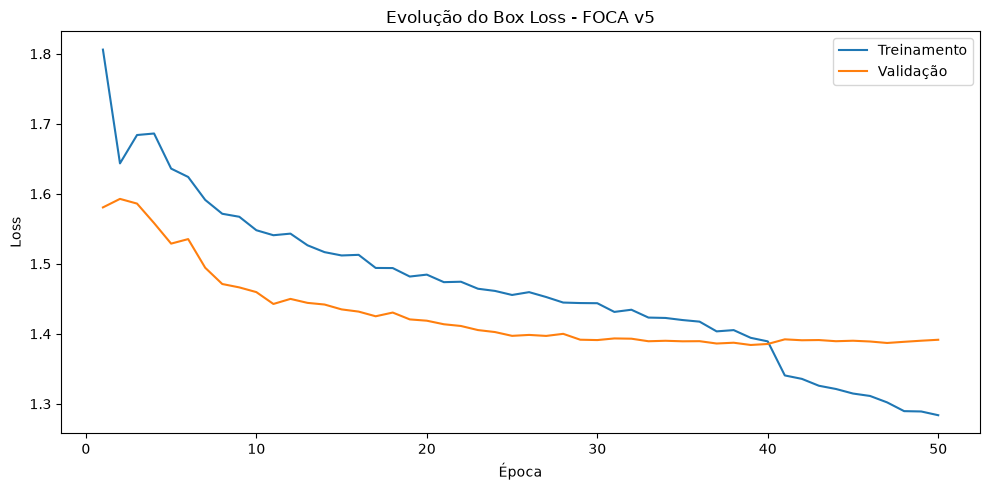

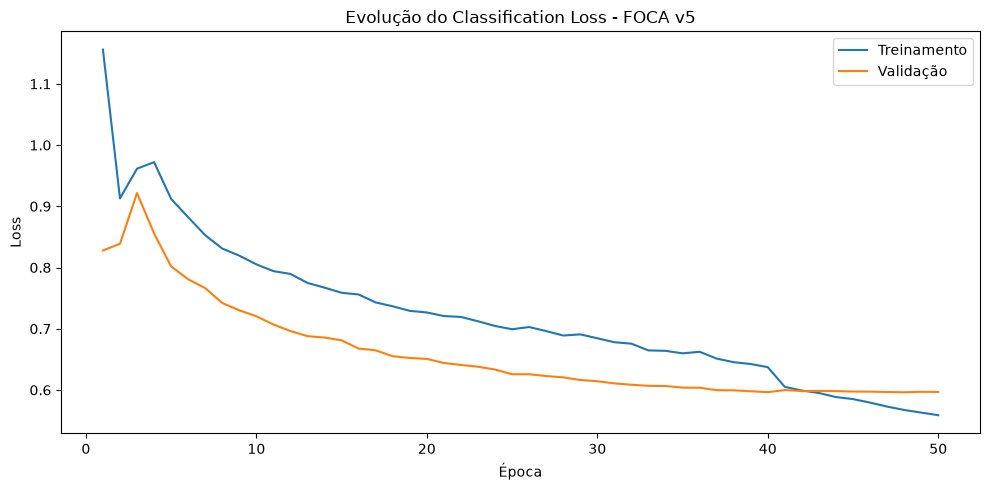

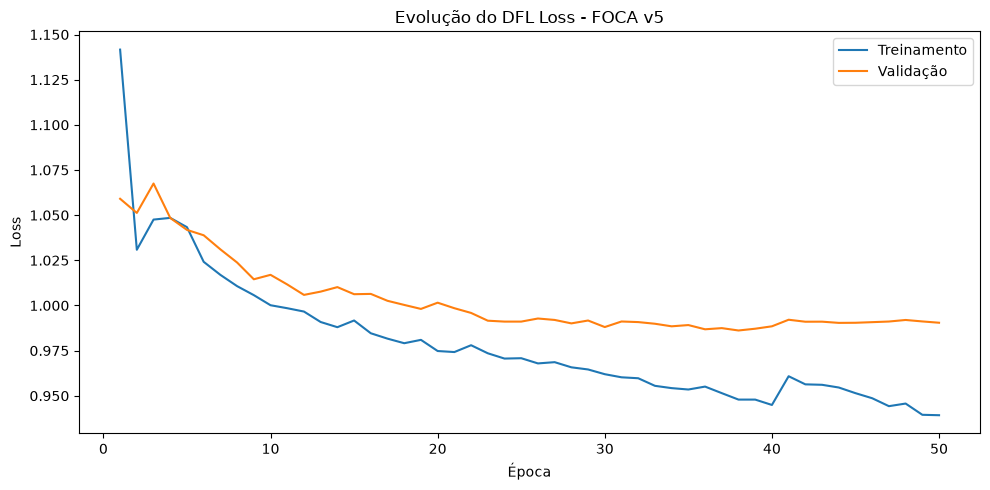

In [13]:
losses = {
    "Box Loss": ("train/box_loss", "val/box_loss"),
    "Classification Loss": ("train/cls_loss", "val/cls_loss"),
    "DFL Loss": ("train/dfl_loss", "val/dfl_loss")
}

for titulo, (train_col, val_col) in losses.items():
    plt.figure(figsize=(10, 5))

    sns.lineplot(
        data=df,
        x="epoch",
        y=train_col,
        label="Treinamento"
    )

    sns.lineplot(
        data=df,
        x="epoch",
        y=val_col,
        label="Validação"
    )

    plt.title(f"Evolução do {titulo} - FOCA v5")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    
    plt.legend()
    plt.tight_layout()

    plt.show()

In [14]:
loss_summary = pd.DataFrame({
    "Loss": [
        "Box Loss",
        "Classification Loss",
        "DFL Loss"
    ],
    
    "Treino inicial": [
        df["train/box_loss"].iloc[0],
        df["train/cls_loss"].iloc[0],
        df["train/dfl_loss"].iloc[0]
    ],
    
    "Treino final": [
        df["train/box_loss"].iloc[-1],
        df["train/cls_loss"].iloc[-1],
        df["train/dfl_loss"].iloc[-1]
    ],
    
    "Validação inicial": [
        df["val/box_loss"].iloc[0],
        df["val/cls_loss"].iloc[0],
        df["val/dfl_loss"].iloc[0]
    ],
    
    "Validação final": [
        df["val/box_loss"].iloc[-1],
        df["val/cls_loss"].iloc[-1],
        df["val/dfl_loss"].iloc[-1]
    ]
})

loss_summary.round(4)

,Loss,Treino inicial,Treino final,Validação inicial,Validação final
0,Box Loss,1.8059,1.2837,1.5805,1.3915
1,Classification Loss,1.1560,0.5588,0.8279,0.5968
2,DFL Loss,1.1416,0.9392,1.0591,0.9904


In [15]:
from matplotlib.ticker import PercentFormatter

metricas_cols = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "mAP@50": "metrics/mAP50(B)",
    "mAP@50:95": "metrics/mAP50-95(B)"
}

comparacao = pd.DataFrame({
    "Métrica": list(metricas_cols.keys()),
    "Época 1": [
        df[col].iloc[0]
        for col in metricas_cols.values()
    ],
    "Época 50": [
        df[col].iloc[-1]
        for col in metricas_cols.values()
    ]
})

comparacao

,Métrica,Época 1,Época 50
0,Precision,0.80603,0.87647
1,Recall,0.55978,0.69421
2,mAP@50,0.64504,0.77878
3,mAP@50:95,0.32541,0.42291


In [16]:
comparacao_long = comparacao.melt(
    id_vars="Métrica",
    var_name="Momento",
    value_name="Valor"
)

comparacao_long

,Métrica,Momento,Valor
0,Precision,Época 1,0.80603
1,Recall,Época 1,0.55978
2,mAP@50,Época 1,0.64504
3,mAP@50:95,Época 1,0.32541
4,Precision,Época 50,0.87647
5,Recall,Época 50,0.69421
6,mAP@50,Época 50,0.77878
7,mAP@50:95,Época 50,0.42291


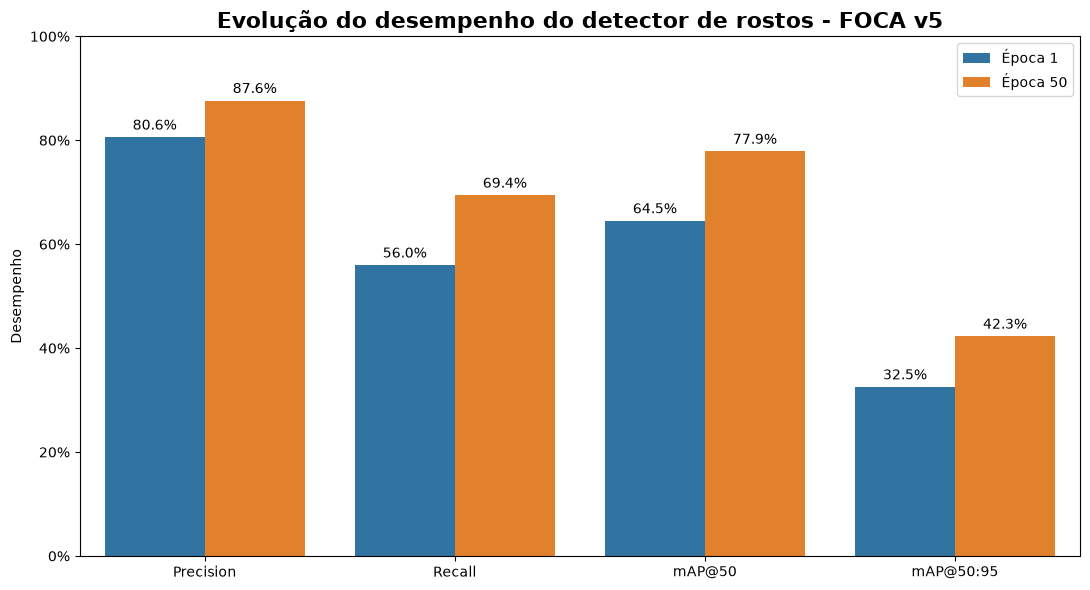

In [17]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparacao_long,
    x="Métrica",
    y="Valor",
    hue="Momento"
)

ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.title(
    "Evolução do desempenho do detector de rostos - FOCA v5",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Desempenho")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x * 100:.1f}%",
        padding=3,
        fontsize=10
    )

plt.legend(title="")
plt.tight_layout()

plt.savefig(
    "evolucao_metricas_colunas_v5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

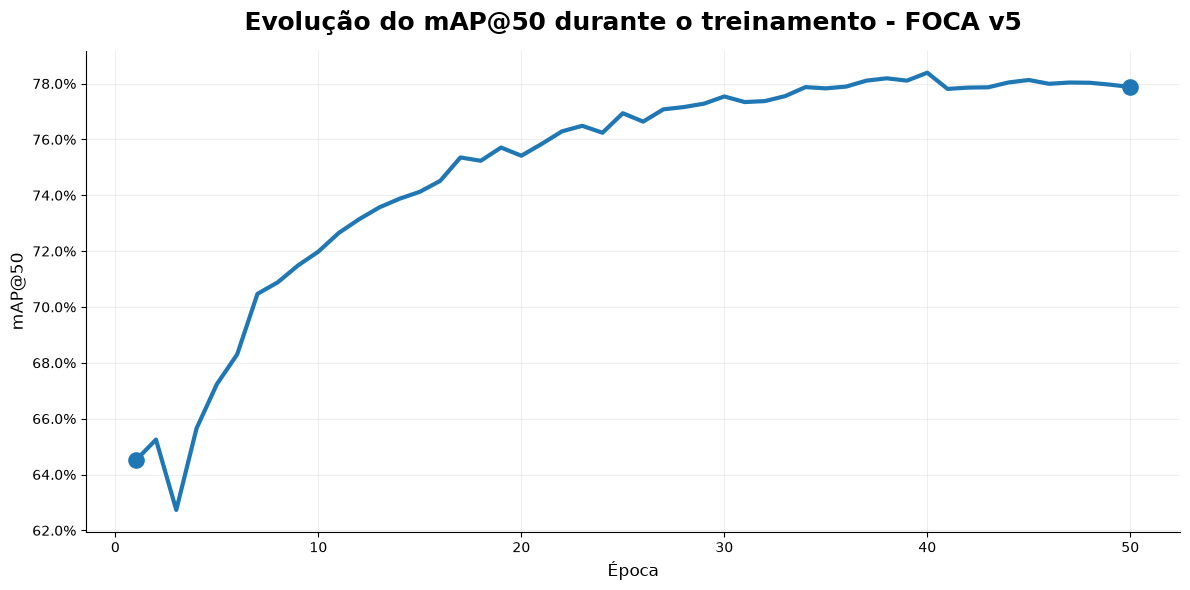

In [18]:
from matplotlib.ticker import PercentFormatter

# Dados
epocas = df["epoch"]
map50 = df["metrics/mAP50(B)"]

map_inicial = map50.iloc[0]
map_final = map50.iloc[-1]

epoca_inicial = epocas.iloc[0]
epoca_final = epocas.iloc[-1]

ganho_pp = (map_final - map_inicial) * 100

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    x=epocas,
    y=map50,
    ax=ax,
    linewidth=3
)

# Pontos inicial e final
ax.scatter(
    [epoca_inicial, epoca_final],
    [map_inicial, map_final],
    s=120,
    zorder=5
)

# # Valor inicial
# ax.annotate(
#     f"{map_inicial:.1%}",
#     xy=(epoca_inicial, map_inicial),
#     xytext=(15, -25),
#     textcoords="offset points",
#     fontsize=12,
#     fontweight="bold"
# )

# # Valor final
# ax.annotate(
#     f"{map_final:.1%}",
#     xy=(epoca_final, map_final),
#     xytext=(-45, 15),
#     textcoords="offset points",
#     fontsize=12,
#     fontweight="bold"
# )

# Configuração
ax.set_title(
    "Evolução do mAP@50 durante o treinamento - FOCA v5",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("mAP@50", fontsize=12)

ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.grid(alpha=0.2)

sns.despine()

plt.tight_layout()

plt.savefig(
    "evolucao_map50_v5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

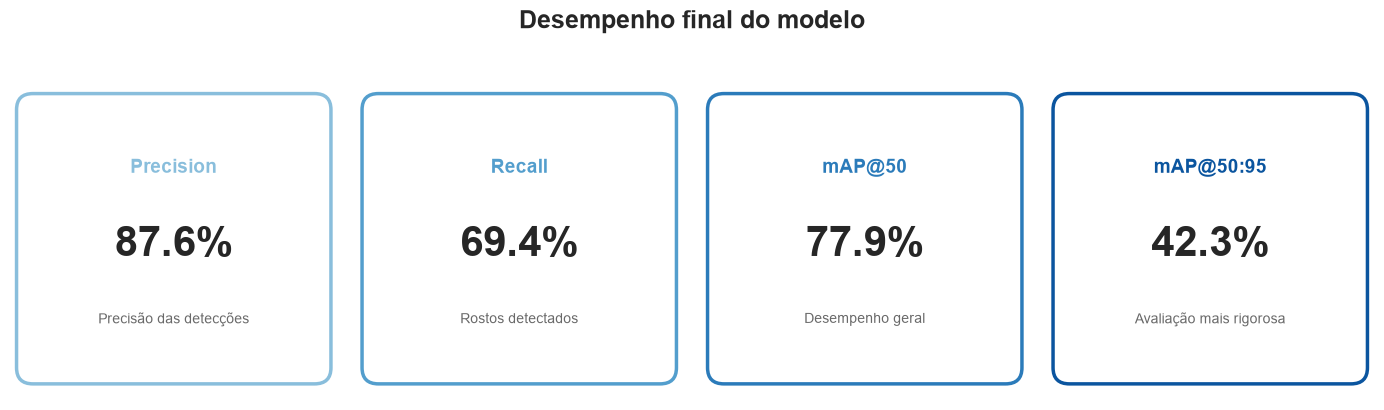

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Valores da última época
metricas_cards = {
    "Precision": df["metrics/precision(B)"].iloc[-1],
    "Recall": df["metrics/recall(B)"].iloc[-1],
    "mAP@50": df["metrics/mAP50(B)"].iloc[-1],
    "mAP@50:95": df["metrics/mAP50-95(B)"].iloc[-1]
}

descricoes = {
    "Precision": "Precisão das detecções",
    "Recall": "Rostos detectados",
    "mAP@50": "Desempenho geral",
    "mAP@50:95": "Avaliação mais rigorosa"
}

sns.set_theme(style="white")

cores = sns.color_palette("Blues", 6)[2:]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(14, 4)
)

for ax, (nome, valor), cor in zip(
    axes,
    metricas_cards.items(),
    cores
):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Card
    card = FancyBboxPatch(
        (0.05, 0.08),
        0.9,
        0.84,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        facecolor="white",
        edgecolor=cor,
        linewidth=2.5
    )

    ax.add_patch(card)

    # Nome da métrica
    ax.text(
        0.5,
        0.72,
        nome,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color=cor
    )

    # Valor principal
    ax.text(
        0.5,
        0.48,
        f"{valor:.1%}",
        ha="center",
        va="center",
        fontsize=30,
        fontweight="bold"
    )

    # Descrição
    ax.text(
        0.5,
        0.25,
        descricoes[nome],
        ha="center",
        va="center",
        fontsize=10,
        color="dimgray"
    )

fig.suptitle(
    "Desempenho final do modelo",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "cards_metricas_finais_v5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparação entre os modelos FOCA v3 e v5

In [7]:
# Troque pelos nomes exatos das suas pastas
model_v3_dir = models_dir / "yolov8_nano_foca_v3_800_50e"
model_v4_dir = models_dir / "yolov8s_foca_v4_800_50e"
model_v5_dir = models_dir / "yolov8_small_foca_v5"

df_v3 = pd.read_csv(
    model_v3_dir / "results.csv",
    skipinitialspace=True
)

# df_v4 = pd.read_csv(
#     model_v4_dir / "results.csv",
#     skipinitialspace=True
# )

df_v5 = pd.read_csv(
    model_v5_dir / "results.csv",
    skipinitialspace=True
)

df_v3.columns = df_v3.columns.str.strip()
# df_v4.columns = df_v4.columns.str.strip()
df_v5.columns = df_v5.columns.str.strip()

print("V3:", len(df_v3), "épocas")
# print("V4:", len(df_v4), "épocas")
print("V5:", len(df_v5), "épocas")

V3: 50 épocas
V5: 50 épocas


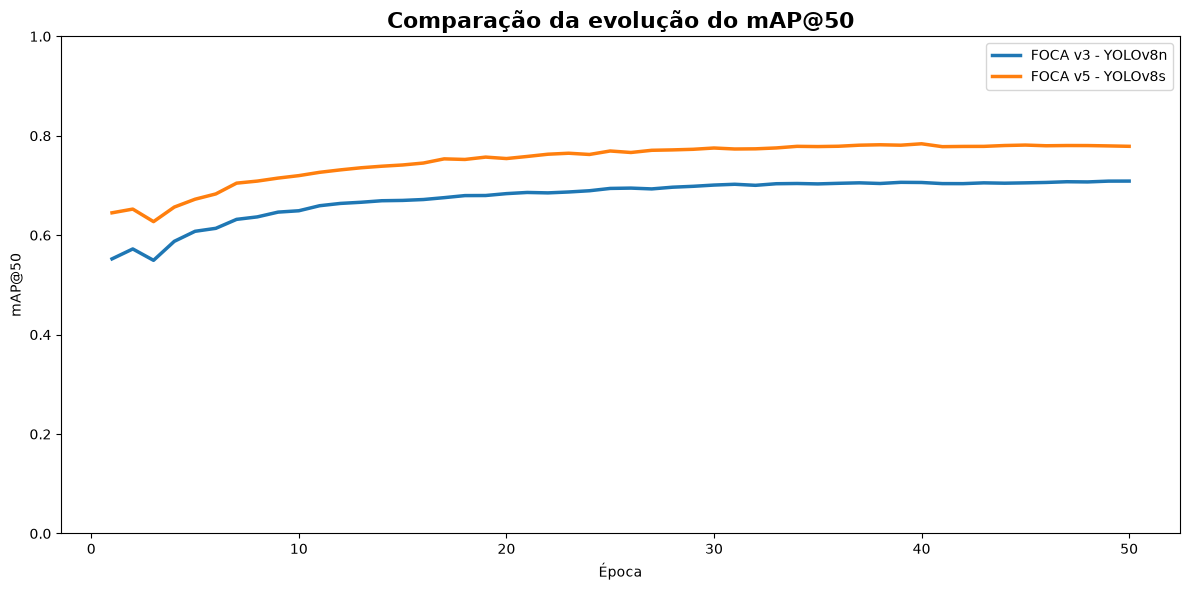

In [8]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_v3,
    x="epoch",
    y="metrics/mAP50(B)",
    label="FOCA v3 - YOLOv8n",
    linewidth=2.5
)

# sns.lineplot(
#     data=df_v4,
#     x="epoch",
#     y="metrics/mAP50(B)",
#     label="FOCA v4 - YOLOv8s",
#     linewidth=2.5
# )

sns.lineplot(
    data=df_v5,
    x="epoch",
    y="metrics/mAP50(B)",
    label="FOCA v5 - YOLOv8s",
    linewidth=2.5
)

plt.title(
    "Comparação da evolução do mAP@50",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Época")
plt.ylabel("mAP@50")

plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "comparacao_map50_v3_v5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

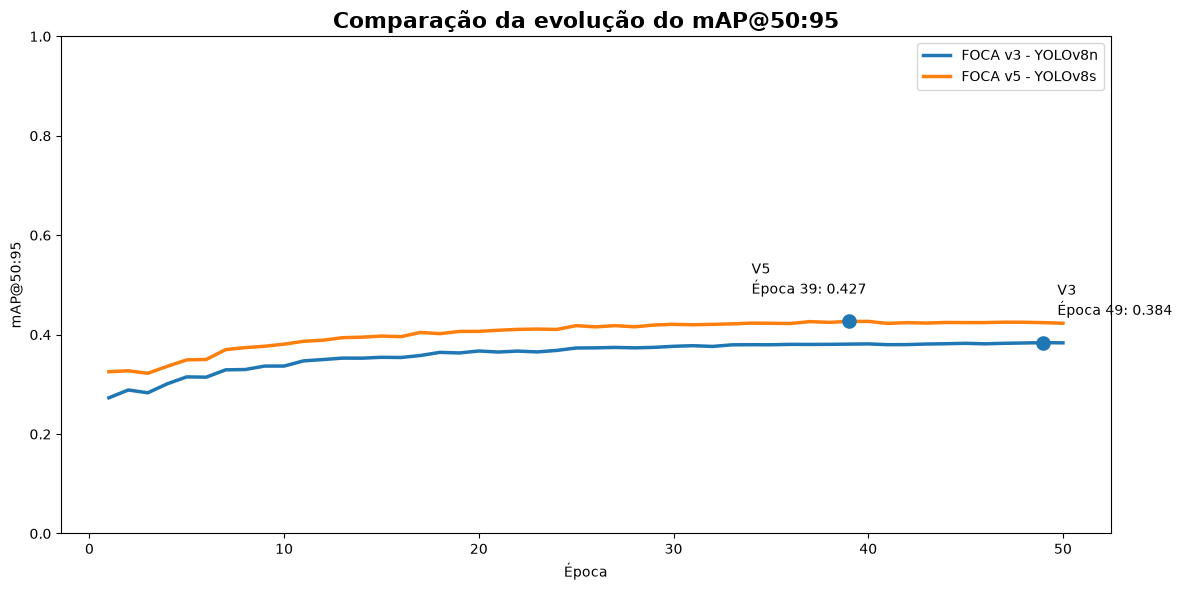

In [9]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_v3,
    x="epoch",
    y="metrics/mAP50-95(B)",
    label="FOCA v3 - YOLOv8n",
    linewidth=2.5
)

# sns.lineplot(
#     data=df_v4,
#     x="epoch",
#     y="metrics/mAP50-95(B)",
#     label="FOCA v4 - YOLOv8s",
#     linewidth=2.5
# )

sns.lineplot(
    data=df_v5,
    x="epoch",
    y="metrics/mAP50-95(B)",
    label="FOCA v5 - YOLOv8s",
    linewidth=2.5
)

# Melhor época V3
idx_v3 = df_v3["metrics/mAP50-95(B)"].idxmax()
epoca_v3 = df_v3.loc[idx_v3, "epoch"]
map_v3 = df_v3.loc[idx_v3, "metrics/mAP50-95(B)"]

# Melhor época V4
# idx_v4 = df_v4["metrics/mAP50-95(B)"].idxmax()
# epoca_v4 = df_v4.loc[idx_v4, "epoch"]
# map_v4 = df_v4.loc[idx_v4, "metrics/mAP50-95(B)"]

# Melhor época V5
idx_v5 = df_v5["metrics/mAP50-95(B)"].idxmax()
epoca_v5 = df_v5.loc[idx_v5, "epoch"]
map_v5 = df_v5.loc[idx_v5, "metrics/mAP50-95(B)"]

plt.scatter(
    [epoca_v3, epoca_v5],
    [map_v3, map_v5],
    s=90,
    zorder=5
)

plt.annotate(
    f"V3\nÉpoca {int(epoca_v3)}: {map_v3:.3f}",
    (epoca_v3, map_v3),
    xytext=(10, 20),
    textcoords="offset points"
)

# plt.annotate(
#     f"V4\nÉpoca {int(epoca_v4)}: {map_v4:.3f}",
#     (epoca_v4, map_v4),
#     xytext=(10, -35),
#     textcoords="offset points"
# )

plt.annotate(
    f"V5\nÉpoca {int(epoca_v5)}: {map_v5:.3f}",
    (epoca_v5, map_v5),
    xytext=(-70, 20),
    textcoords="offset points"
)

plt.title(
    "Comparação da evolução do mAP@50:95",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Época")
plt.ylabel("mAP@50:95")

plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "comparacao_map50_95_v3_v4_v5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
metricas_cols = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "mAP@50": "metrics/mAP50(B)",
    "mAP@50:95": "metrics/mAP50-95(B)"
}

idx_v3 = df_v3["metrics/mAP50-95(B)"].idxmax()
# idx_v4 = df_v4["metrics/mAP50-95(B)"].idxmax()
idx_v5 = df_v5["metrics/mAP50-95(B)"].idxmax()

melhor_v3 = df_v3.loc[idx_v3]
# melhor_v4 = df_v4.loc[idx_v4]
melhor_v5 = df_v5.loc[idx_v5]

comparacao_modelos = pd.DataFrame({
    "Métrica": list(metricas_cols.keys()),
    "FOCA v3 - YOLOv8n": [
        melhor_v3[col]
        for col in metricas_cols.values()
    ],
    # "FOCA v4 - YOLOv8s": [
    #     melhor_v4[col]
    #     for col in metricas_cols.values()
    # ],
    "FOCA v5 - YOLOv8s": [
        melhor_v5[col]
        for col in metricas_cols.values()
    ]
})

comparacao_modelos

,Métrica,FOCA v3 - YOLOv8n,FOCA v5 - YOLOv8s
0,Precision,0.86300,0.87289
1,Recall,0.63485,0.69701
2,mAP@50,0.70876,0.78105
3,mAP@50:95,0.38387,0.42665


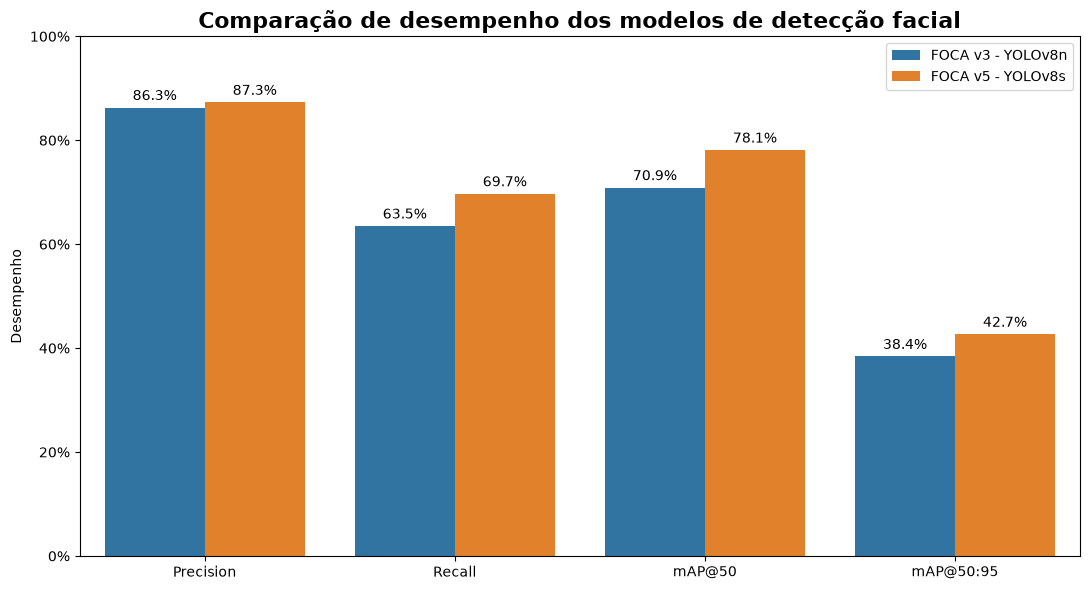

In [11]:
from matplotlib.ticker import PercentFormatter

comparacao_long = comparacao_modelos.melt(
    id_vars="Métrica",
    var_name="Modelo",
    value_name="Valor"
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparacao_long,
    x="Métrica",
    y="Valor",
    hue="Modelo"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)

plt.title(
    "Comparação de desempenho dos modelos de detecção facial",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Desempenho")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x * 100:.1f}%",
        padding=3,
        fontsize=10
    )

plt.legend(
    title="",
    loc="upper right"
)

plt.tight_layout()

plt.savefig(
    "comparacao_metricas_v3_v5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Validação comparativa dos modelos no mesmo conjunto de dados

In [12]:
from pathlib import Path
from ultralytics import YOLO
import pandas as pd

# Ajuste apenas se suas pastas estiverem em outro lugar
models_dir = Path("../models")
dataset_yaml = Path("dataset_foca_v4/data.yaml")

modelo_v3_path = (
    models_dir
    / "yolov8_nano_foca_v3_800_50e"
    / "weights"
    / "best.pt"
)

# modelo_v4_path = (
#     models_dir
#     / "yolov8s_foca_v4_800_50e"
#     / "weights"
#     / "best.pt"
# )

modelo_v5_path = (
    models_dir
    / "yolov8_small_foca_v5"
    / "weights"
    / "best.pt"
)

print("Dataset:", dataset_yaml.resolve())
print("V3:", modelo_v3_path.resolve())
# print("V4:", modelo_v4_path.resolve())
print("V5:", modelo_v5_path.resolve())

print("\nArquivos encontrados:")
print("Dataset:", dataset_yaml.exists())
print("V3:", modelo_v3_path.exists())
# print("V4:", modelo_v4_path.exists())
print("V5:", modelo_v5_path.exists())

Dataset: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\data.yaml
V3: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\models\yolov8_nano_foca_v3_800_50e\weights\best.pt
V5: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\models\yolov8_small_foca_v5\weights\best.pt

Arquivos encontrados:
Dataset: True
V3: True
V5: True


In [ ]:
def validar_modelo(nome, caminho_modelo):
    print(f"\n{'=' * 60}")
    print(f"Validando {nome}")
    print(f"{'=' * 60}")

    model = YOLO(str(caminho_modelo))

    metrics = model.val(
        data=str(dataset_yaml),
        split="val",
        imgsz=800,
        batch=1,
        device=0,
        workers=0,
        plots=True,

        project=str(models_dir / "comparacao_validacao"),
        name=nome.replace(" ", "_").lower()
    )

    return metrics


metrics_v3 = validar_modelo(
    "FOCA V3 YOLOv8n",
    modelo_v3_path
)

# metrics_v4 = validar_modelo(
#     "FOCA V4 YOLOv8s",
#     modelo_v4_path
# )

metrics_v5 = validar_modelo(
    "FOCA V5 YOLOv8s",
    modelo_v5_path
)


Validando FOCA V3 YOLOv8n
Ultralytics 8.4.148  Python-3.11.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce MX570 A, 2048MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.70.1 ms, read: 84.116.0 MB/s, size: 290.5 KB)
val: Scanning C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\val\labels.cache... 2576 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 2576/2576  0.0s
val: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\val\images\wider_10969.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0253906]
val: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\val\images\wider_3232.jpg: 1 duplicate labels removed
val: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\val\images\wider_7207.jpg: 1 duplicate labels removed
WARNING Dataset images contain up to 1146 objects (val=1146), but m

In [ ]:
def extrair_metricas(nome, metrics):
    r = metrics.results_dict

    return {
        "Modelo": nome,
        "Precision": r["metrics/precision(B)"],
        "Recall": r["metrics/recall(B)"],
        "mAP@50": r["metrics/mAP50(B)"],
        "mAP@50:95": r["metrics/mAP50-95(B)"],
    }


comparacao = pd.DataFrame([
    extrair_metricas(
        "FOCA V3 - YOLOv8n",
        metrics_v3
    ),
    # extrair_metricas(
    #     "FOCA V4 - YOLOv8s",
    #     metrics_v4
    # ),
    extrair_metricas(
        "FOCA V5 - YOLOv8s",
        metrics_v5
    )
])

comparacao

,Modelo,Precision,Recall,mAP@50,mAP@50:95
0,FOCA V3 - YOLOv8n,0.835231,0.615271,0.697974,0.368673
1,FOCA V4 - YOLOv8s,0.841159,0.597163,0.680955,0.345941


In [53]:
comparacao_formatada = comparacao.copy()

for col in ["Precision", "Recall", "mAP@50", "mAP@50:95"]:
    comparacao_formatada[col] = (
        comparacao_formatada[col] * 100
    ).round(2).astype(str) + "%"

comparacao_formatada

,Modelo,Precision,Recall,mAP@50,mAP@50:95
0,FOCA V3 - YOLOv8n,83.52%,61.53%,69.8%,36.87%
1,FOCA V4 - YOLOv8s,84.12%,59.72%,68.1%,34.59%


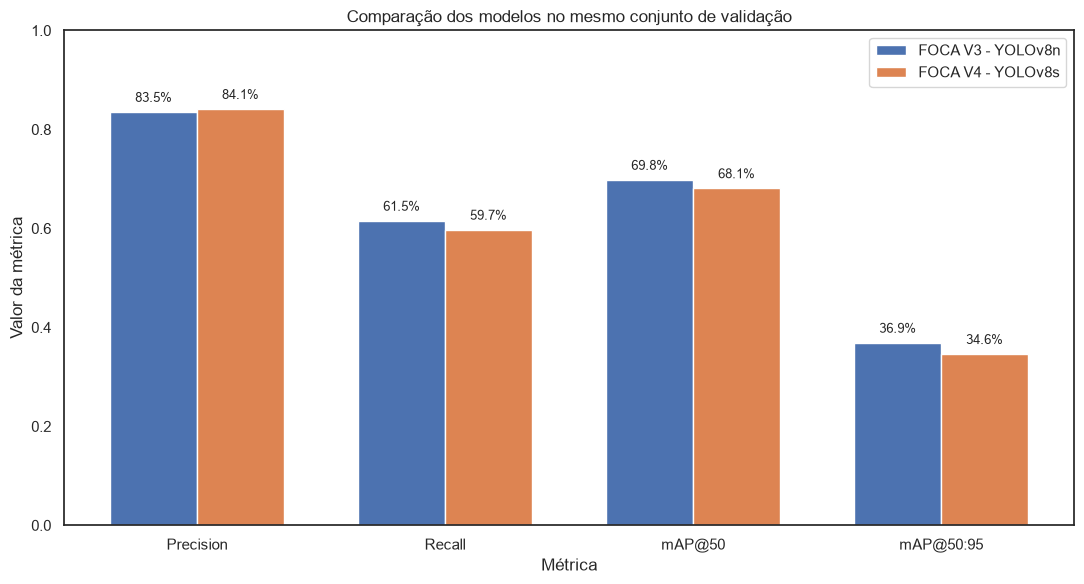

In [54]:
import matplotlib.pyplot as plt
import numpy as np

metricas = [
    "Precision",
    "Recall",
    "mAP@50",
    "mAP@50:95"
]

valores_v3 = comparacao.loc[
    comparacao["Modelo"] == "FOCA V3 - YOLOv8n",
    metricas
].iloc[0].values.astype(float)

valores_v4 = comparacao.loc[
    comparacao["Modelo"] == "FOCA V4 - YOLOv8s",
    metricas
].iloc[0].values.astype(float)

x = np.arange(len(metricas))
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

barras_v3 = ax.bar(
    x - largura / 2,
    valores_v3,
    largura,
    label="FOCA V3 - YOLOv8n"
)

barras_v4 = ax.bar(
    x + largura / 2,
    valores_v4,
    largura,
    label="FOCA V4 - YOLOv8s"
)

ax.set_title(
    "Comparação dos modelos no mesmo conjunto de validação"
)

ax.set_ylabel("Valor da métrica")
ax.set_xlabel("Métrica")

ax.set_xticks(x)
ax.set_xticklabels(metricas)

ax.set_ylim(0, 1)

ax.legend()

for barras in [barras_v3, barras_v4]:
    for barra in barras:
        valor = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.015,
            f"{valor * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "comparacao_modelos_mesma_validacao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

coparando velocidades

In [55]:
print("V3:")
print(metrics_v3.speed)

print("\nV4:")
print(metrics_v4.speed)

V3:
{'preprocess': 3.4734823300830397, 'inference': 54.23760450488064, 'loss': 0.016944699024146387, 'postprocess': 4.0101472621651375}

V4:
{'preprocess': 0.9492193786012013, 'inference': 20.161121864058586, 'loss': 0.010166213548464195, 'postprocess': 2.680009436903542}


In [56]:
velocidade = pd.DataFrame([
    {
        "Modelo": "FOCA V3 - YOLOv8n",
        "Inferência (ms/imagem)": metrics_v3.speed["inference"],
        "Pré-processamento": metrics_v3.speed["preprocess"],
        "Pós-processamento": metrics_v3.speed["postprocess"]
    },
    {
        "Modelo": "FOCA V4 - YOLOv8s",
        "Inferência (ms/imagem)": metrics_v4.speed["inference"],
        "Pré-processamento": metrics_v4.speed["preprocess"],
        "Pós-processamento": metrics_v4.speed["postprocess"]
    }
])

velocidade

,Modelo,Inferência (ms/imagem),Pré-processamento,Pós-processamento
0,FOCA V3 - YOLOv8n,54.237605,3.473482,4.010147
1,FOCA V4 - YOLOv8s,20.161122,0.949219,2.680009


In [28]:
from ultralytics import YOLO
import torch

def testar_velocidade(nome, caminho):
    model = YOLO(str(caminho))

    # Aquecimento
    print(f"Aquecendo {nome}...")
    model.val(
        data=str(dataset_yaml),
        split="val",
        imgsz=800,
        batch=1,
        device=0,
        workers=0,
        plots=False,
        verbose=False
    )

    torch.cuda.empty_cache()

    # Medição
    print(f"Medindo {nome}...")
    metrics = model.val(
        data=str(dataset_yaml),
        split="val",
        imgsz=800,
        batch=1,
        device=0,
        workers=0,
        plots=False,
        verbose=False
    )

    return metrics.speed

In [58]:
speed_v4 = testar_velocidade(
    "FOCA V4 - YOLOv8s",
    modelo_v4_path
)

torch.cuda.empty_cache()

speed_v3 = testar_velocidade(
    "FOCA V3 - YOLOv8n",
    modelo_v3_path
)

print("V3:", speed_v3)
print("V4:", speed_v4)

Aquecendo FOCA V4 - YOLOv8s...
Ultralytics 8.4.148  Python-3.11.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce MX570 A, 2048MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2113.2652.4 MB/s, size: 259.8 KB)
val: Scanning C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\val\labels.cache... 2576 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 2576/2576  0.0s
val: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\val\images\wider_10969.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0253906]
val: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\val\images\wider_3232.jpg: 1 duplicate labels removed
val: C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\dataset_foca_v4\val\images\wider_7207.jpg: 1 duplicate labels removed
WARNING Dataset images contain up to 1146 objects (val=114

# Rodando validações de novo

In [13]:
import kagglehub
from pathlib import Path
import os
import yaml

print("Baixando/localizando WIDER FACE...")

dataset_path = Path(
    kagglehub.dataset_download(
        "canomercik/wider-face-dataset-for-yolov12-format"
    )
)

print("Dataset:", dataset_path)

c:\Users\cooki\Documents\GitHub\FOCA\Source\AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Baixando/localizando WIDER FACE...
Dataset: C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5


In [14]:
base_dir = None

for root, dirs, files in os.walk(dataset_path):
    root_path = Path(root)

    if (
        (root_path / "train" / "images").exists()
        and
        (root_path / "val" / "images").exists()
    ):
        base_dir = root_path
        break

if base_dir is None:
    raise FileNotFoundError(
        "Não encontrei as pastas train/images e val/images."
    )

print("Base encontrada:")
print(base_dir)

print("\nTreino:")
print(base_dir / "train" / "images")

print("\nValidação:")
print(base_dir / "val" / "images")

Base encontrada:
C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12

Treino:
C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12\train\images

Validação:
C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12\val\images


In [22]:
extensoes = {".jpg", ".jpeg", ".png"}

train_images = [
    p for p in (base_dir / "train" / "images").iterdir()
    if p.suffix.lower() in extensoes
]

val_images = [
    p for p in (base_dir / "val" / "images").iterdir()
    if p.suffix.lower() in extensoes
]

print("Treino:", len(train_images))
print("Validação:", len(val_images))

Treino: 12880
Validação: 3226


In [23]:
yaml_comparacao = Path("wider_face_comparacao.yaml")

dados_yaml = {
    "path": str(base_dir.resolve()),
    "train": "train/images",
    "val": "val/images",
    "nc": 1,
    "names": ["face"]
}

with open(yaml_comparacao, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        dados_yaml,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print("YAML criado em:")
print(yaml_comparacao.resolve())

YAML criado em:
C:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks\wider_face_comparacao.yaml


In [24]:
v4_train_dir = Path("dataset_foca_v4/train/images")

nomes_v4_train = {
    p.name for p in v4_train_dir.iterdir()
    if p.suffix.lower() in extensoes
}

nomes_val_oficial = {
    p.name for p in (base_dir / "val" / "images").iterdir()
    if p.suffix.lower() in extensoes
}

sobreposicao = nomes_v4_train & nomes_val_oficial

print("Imagens em comum:", len(sobreposicao))

if sobreposicao:
    print("Exemplos:")
    print(list(sobreposicao)[:10])
else:
    print("Ótimo: nenhum arquivo da validação aparece no treino do V4.")

Imagens em comum: 0
Ótimo: nenhum arquivo da validação aparece no treino do V4.


In [25]:
from ultralytics import YOLO

modelo_v3_path = (
    models_dir
    / "yolov8_nano_foca_v3_800_50e"
    / "weights"
    / "best.pt"
)

# modelo_v4_path = (
#     models_dir
#     / "yolov8s_foca_v4_800_50e"
#     / "weights"
#     / "best.pt"
# )

modelo_v5_path = (
    models_dir
    / "yolov8_small_foca_v5"
    / "weights"
    / "best.pt"
)

print("V3:", modelo_v3_path.exists(), modelo_v3_path)
# print("V4:", modelo_v4_path.exists(), modelo_v4_path)
print("V5:", modelo_v5_path.exists(), modelo_v5_path)

V3: True ..\models\yolov8_nano_foca_v3_800_50e\weights\best.pt
V5: True ..\models\yolov8_small_foca_v5\weights\best.pt


In [26]:
def validar_modelo(nome, caminho_modelo):
    print("\n" + "=" * 70)
    print(nome)
    print("=" * 70)

    model = YOLO(str(caminho_modelo))

    metrics = model.val(
        data=str(yaml_comparacao),
        split="val",
        imgsz=800,
        batch=1,
        device=0,
        workers=0,
        plots=True,
        verbose=True,
        project=str(models_dir / "comparacao_wider_oficial"),
        name=nome
    )

    return metrics

In [27]:
metrics_v3_oficial = validar_modelo(
    "FOCA_V3_YOLOv8n",
    modelo_v3_path
)


FOCA_V3_YOLOv8n
Ultralytics 8.4.148  Python-3.11.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce MX570 A, 2048MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1232.5415.2 MB/s, size: 103.1 KB)
val: Scanning C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12\val\labels.cache... 3226 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3226/3226  0.0s
val: C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12\val\images\21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
WARNING Dataset images contain up to 709 objects (val=709), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or ex

In [37]:
metrics_v4_oficial = validar_modelo(
    "FOCA_V4_YOLOv8s",
    modelo_v4_path
)


FOCA_V4_YOLOv8s
Ultralytics 8.4.148  Python-3.11.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce MX570 A, 2048MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1487.7457.4 MB/s, size: 131.9 KB)
val: Scanning C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12\val\labels.cache... 3226 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3226/3226  0.0s
val: C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12\val\images\21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
WARNING Dataset images contain up to 709 objects (val=709), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or 

In [28]:
metrics_v5_oficial = validar_modelo(
    "FOCA_V5_YOLOv8s",
    modelo_v5_path
)


FOCA_V5_YOLOv8s
Ultralytics 8.4.148  Python-3.11.9 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce MX570 A, 2048MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1132.3356.0 MB/s, size: 109.5 KB)
val: Scanning C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12\val\labels.cache... 3226 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3226/3226  0.0s
val: C:\Users\cooki\.cache\kagglehub\datasets\canomercik\wider-face-dataset-for-yolov12-format\versions\5\WIDER Face Dataset For YOLOv12\WIDER Face Dataset For YOLOv12\val\images\21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
WARNING Dataset images contain up to 709 objects (val=709), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or 

In [29]:
import pandas as pd

def metricas_para_dict(nome, resultado):
    r = resultado.results_dict

    return {
        "Modelo": nome,
        "Precision": r["metrics/precision(B)"],
        "Recall": r["metrics/recall(B)"],
        "mAP@50": r["metrics/mAP50(B)"],
        "mAP@50:95": r["metrics/mAP50-95(B)"],
        "Inferência (ms/imagem)": resultado.speed["inference"]
    }

comparacao_oficial = pd.DataFrame([
    metricas_para_dict(
        "FOCA V3 - YOLOv8n",
        metrics_v3_oficial
    ),
    # metricas_para_dict(
    #     "FOCA V4 - YOLOv8s",
    #     metrics_v4_oficial
    # ),
    metricas_para_dict(
        "FOCA V5 - YOLOv8s",
        metrics_v5_oficial
    )
])

comparacao_oficial

,Modelo,Precision,Recall,mAP@50,mAP@50:95,Inferência (ms/imagem)
0,FOCA V3 - YOLOv8n,0.856704,0.645000,0.732593,0.392945,10.519589
1,FOCA V5 - YOLOv8s,0.874719,0.699146,0.780024,0.427945,21.224617


In [30]:
comparacao_formatada = comparacao_oficial.copy()

for coluna in [
    "Precision",
    "Recall",
    "mAP@50",
    "mAP@50:95"
]:
    comparacao_formatada[coluna] = (
        comparacao_formatada[coluna] * 100
    ).map(lambda x: f"{x:.2f}%")

comparacao_formatada["Inferência (ms/imagem)"] = (
    comparacao_formatada["Inferência (ms/imagem)"]
    .map(lambda x: f"{x:.2f}")
)

comparacao_formatada

,Modelo,Precision,Recall,mAP@50,mAP@50:95,Inferência (ms/imagem)
0,FOCA V3 - YOLOv8n,85.67%,64.50%,73.26%,39.29%,10.52
1,FOCA V5 - YOLOv8s,87.47%,69.91%,78.00%,42.79%,21.22


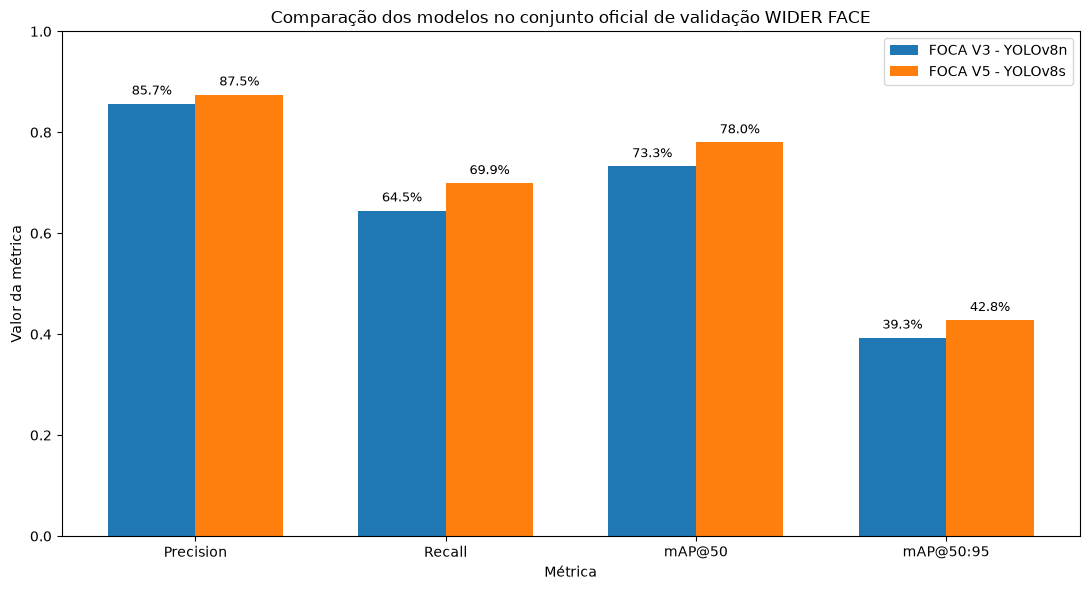

In [33]:
import matplotlib.pyplot as plt
import numpy as np

metricas = [
    "Precision",
    "Recall",
    "mAP@50",
    "mAP@50:95"
]

v3 = comparacao_oficial.iloc[0][metricas].astype(float).values
# v4 = comparacao_oficial.iloc[1][metricas].astype(float).values
v5 = comparacao_oficial.iloc[1][metricas].astype(float).values

x = np.arange(len(metricas))
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars_v3 = ax.bar(
    x - largura / 2,
    v3,
    largura,
    label="FOCA V3 - YOLOv8n"
)

# bars_v4 = ax.bar(
#     x + largura / 2,
#     v4,
#     largura,
#     label="FOCA V4 - YOLOv8s"
# )

bars_v5 = ax.bar(
    x + largura / 2,
    v5,
    largura,
    label="FOCA V5 - YOLOv8s"
)

ax.set_title(
    "Comparação dos modelos no conjunto oficial de validação WIDER FACE"
)

ax.set_xlabel("Métrica")
ax.set_ylabel("Valor da métrica")

ax.set_xticks(x)
ax.set_xticklabels(metricas)

ax.set_ylim(0, 1)
ax.legend()

for barras in [bars_v3, bars_v5]:
    for barra in barras:
        valor = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.012,
            f"{valor * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    "comparacao_v3_v5_wider_oficial.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()